 # CHN vs DHN Comparison - Publication Summary Figure

 ## Overview

 This script generates a **condensed, publication-ready figure** comparing Autonomous
 Recollection (AR) in Continuous Hopfield Networks (CHN) with Hebbian and Storkey
 learning rules in Discrete Hopfield Networks (DHN).

 Unlike the full `viz_comparison.py` which generates extensive grid plots, this script
 produces a single, focused figure suitable for publication.

 ---

 ## Methods Compared

 ### 1. AR (CHN) - Autonomous Retrieval with Sleep-Based Consolidation
 - **Mechanism**: Patterns are stored via gradient descent training, then retrieved
   autonomously during "sleep" cycles without any external cues
 - **Success metric**: `all_recovered_before_spurious` - whether all patterns were
   recovered before any spurious attractor appeared
 - **Key advantage**: No external cues required; the network spontaneously retrieves
   stored patterns through internal dynamics

 ### 2. Hebbian (DHN) - Classic Outer-Product Learning Rule
 - **Mechanism**: Weights computed as sum of outer products: W = (1/N) Σ ξ_μ ξ_μ^T
 - **Retrieval**: Requires partial cue (subset of pattern bits) to retrieve full pattern
 - **Theoretical capacity**: ~N / (2 ln N) patterns (asymptotic)
 - **Success metric**: `query_success_rate` - fraction of patterns successfully retrieved

 ### 3. Storkey (DHN) - Local-Field Corrected Learning Rule
 - **Mechanism**: Incremental learning with local field corrections to reduce interference
 - **Retrieval**: Same partial-cue mechanism as Hebbian
 - **Theoretical capacity**: ~N / (4 √(2 ln N)) - approximately 3x better than Hebbian
 - **Success metric**: Same as Hebbian

 ---

 ## Methodological Choices & Justifications

 ### Why 50% Informed Fraction?

 DHN methods require a partial cue to retrieve patterns. The `informed_fraction` parameter
 controls what fraction of pattern bits are provided as the initial cue.

 We use **50% informed fraction** because:
 - It represents a balanced, realistic retrieval scenario
 - **Critically**: Varying informed fraction (10%-90%) does NOT qualitatively change the
   competition between methods. AR maintains its relative advantage at higher ρ values
   regardless of whether DHN uses 10% or 90% cues.
 - The full comparison (`viz_comparison.py`) confirms this across all informed fractions

 ### Why 90% Success Threshold?

 Storage capacity is defined as the maximum number of patterns where success rate ≥ threshold.

 We use **90% threshold** because:
 - Strict threshold ensures reliable, robust pattern storage
 - Lower thresholds (80%, 50%) show qualitatively similar results
 - For scientific claims about "reliable storage", a high threshold is appropriate

 ### Why Exclude ρ=0.8?

 Pattern correlation ρ controls how similar stored patterns are (ρ=1 means identical,
 ρ=0 means maximally different/uncorrelated).

 We exclude ρ=0.8 because:
 - At high correlation, patterns become nearly indistinguishable
 - **All methods achieve near-zero capacity at ρ=0.8**
 - Including it would add visual clutter without meaningful information
 - The interesting competition happens at ρ ∈ [0.0, 0.6]

 ### Saturation Markers (▲)

 Triangle markers indicate that DHN capacity has reached the maximum tested (99 patterns).
 This means:
 - The true capacity may be higher than shown
 - The curve is truncated by our parameter sweep limits
 - This primarily affects Storkey at low ρ with large networks

 ---

 ## Expected Results

 Based on the underlying physics of each method:

 | ρ value | Expected Winner | Explanation |
 |---------|-----------------|-------------|
 | 0.0 | Storkey > Hebbian > AR | Uncorrelated patterns favor DHN's theoretical capacity |
 | 0.2 | Storkey ≈ Hebbian > AR | Transition region, Storkey may saturate |
 | 0.4 | AR competitive | AR benefits from correlation structure |
 | 0.5 | AR outperforms DHN | Optimal regime for AR's correlation exploitation |
 | 0.6 | AR > DHN | DHN struggles with highly correlated patterns |

 ---

 ## Output

 - **File**: `scripts/plots/comparison_summary.png`
 - **Layout**: 1 row × 5 columns (one subplot per ρ value)
 - **Dimensions**: 20" × 4.5" (wide format suitable for publications)

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

sys.path.insert(0, str(Path(__file__).parent.parent))
from utils import DATA_DIR

In [ ]:
# CONFIGURATION
# =============================================================================

# Output settings
OUTPUT_DIR = Path(__file__).parent.parent / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PLOTS = True
DPI = 300

# Method styles (sober color scheme, same markers/lines)
METHOD_COLORS = {
    'AR':      '#2C3E50',  # Dark blue-gray
    'Hebbian': '#922B21',  # Dark burgundy
    'Storkey': '#1E8449',  # Dark forest green
}

METHOD_STYLES = {
    'AR':      {'color': METHOD_COLORS['AR'],      'marker': 'o', 'linestyle': '-', 'markersize': 10, 'linewidth': 2.5},
    'Hebbian': {'color': METHOD_COLORS['Hebbian'], 'marker': 'o', 'linestyle': '-', 'markersize': 10, 'linewidth': 2.5},
    'Storkey': {'color': METHOD_COLORS['Storkey'], 'marker': 'o', 'linestyle': '-', 'markersize': 10, 'linewidth': 2.5},
}

# --- Summary-specific parameters ---
RHO_VALUES = [0.0, 0.2, 0.4, 0.5, 0.6]  # Exclude 0.8 (all methods ~0 capacity)
INFORMED_FRACTION = 0.5                   # Fixed at 50%
SUCCESS_THRESHOLD = 0.9                   # 90% only

# DHN saturation limits
DHN_MAX_TESTED_PATTERNS = 99
DHN_SATURATION_THRESHOLD = 97

In [ ]:
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=1.8)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times']
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'legend.fontsize': 21,
    'figure.titlesize': 26,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'axes.grid': False,
    'font.weight': 'bold'
})

In [ ]:
# DATA LOADING FUNCTIONS (reused from viz_comparison.py)
# =============================================================================

def load_chn_data():
    """
    Load and merge CHN data from multiple sources.

    Sources (rho = 0.0, 0.2, 0.4, 0.6, 0.8):
    - capacity_scaling_larger_small_sleep: network_size [300-500], num_patterns [5-39]
    - capacity_scaling_larger_large_sleep: network_size [1000], num_patterns [10-49]
    - SR_correlation_compatible_large_sleep: network_size [100, 200], num_patterns [1-24]

    Sources (rho = 0.5):
    - capacity_scaling_larger_0.5_small_sleep: network_size [300-500], num_patterns [5-39]
    - capacity_scaling_larger_0.5_large_sleep: network_size [1000], num_patterns [10-49]
    - SR_correlation_0.5_compatible_large_sleep: network_size [100, 200], num_patterns [1-24]

    Returns:
        pd.DataFrame: Merged CHN data with all network sizes and pattern counts
    """
    sources = [
        # Original sources (rho = 0.0, 0.2, 0.4, 0.6, 0.8)
        "capacity_scaling_larger_small_sleep",
        "capacity_scaling_larger_large_sleep",
        "SR_correlation_compatible_large_sleep",
        # New sources for rho = 0.5
        "capacity_scaling_larger_0.5_small_sleep",
        "capacity_scaling_larger_0.5_large_sleep",
        "SR_correlation_0.5_compatible_large_sleep",
    ]

    dfs = []
    for source in sources:
        path = DATA_DIR / "sleep_results" / source / "final_results.csv"
        if path.exists():
            df = pd.read_csv(path)
            df['source'] = source
            dfs.append(df)
            print(f"  Loaded {len(df)} rows from {source}")
        else:
            print(f"  WARNING: {source} not found at {path}")

    if not dfs:
        return None

    merged = pd.concat(dfs, ignore_index=True)
    print(f"\n  Total CHN rows: {len(merged)}")
    return merged


def load_dhn_data():
    """
    Load DHN data for Hebbian and Storkey learning rules.

    Returns:
        tuple: (hebbian_df, storkey_df)
    """
    # Hebbian sources
    hebbian_sources = [
        "comparison_dhn_hebbian_query",      # rho = 0.0, 0.2, 0.4, 0.6, 0.8
        "comparison_dhn_hebbian_query_0.5",  # rho = 0.5
    ]

    # Storkey sources
    storkey_sources = [
        "comparison_dhn_storkey_query",      # rho = 0.0, 0.2, 0.4, 0.6, 0.8
        "comparison_dhn_storkey_query_0.5",  # rho = 0.5
    ]

    # Load and merge Hebbian data
    hebbian_dfs = []
    for source in hebbian_sources:
        path = DATA_DIR / "query_results" / source / "final_results.csv"
        if path.exists():
            df = pd.read_csv(path)
            hebbian_dfs.append(df)
            print(f"  Loaded {len(df)} Hebbian rows from {source}")
        else:
            print(f"  WARNING: Hebbian data not found at {path}")

    hebbian_df = pd.concat(hebbian_dfs, ignore_index=True) if hebbian_dfs else None

    # Load and merge Storkey data
    storkey_dfs = []
    for source in storkey_sources:
        path = DATA_DIR / "query_results" / source / "final_results.csv"
        if path.exists():
            df = pd.read_csv(path)
            storkey_dfs.append(df)
            print(f"  Loaded {len(df)} Storkey rows from {source}")
        else:
            print(f"  WARNING: Storkey data not found at {path}")

    storkey_df = pd.concat(storkey_dfs, ignore_index=True) if storkey_dfs else None

    return hebbian_df, storkey_df

In [ ]:
# HELPER FUNCTIONS (reused from viz_comparison.py)
# =============================================================================

def filter_by_rho(df, rho, col='rho', atol=1e-6):
    """Filter DataFrame by rho value (handles float precision)."""
    return df[np.isclose(df[col], rho, atol=atol)]


def filter_by_informed(df, informed, col='informed_fraction', atol=1e-6):
    """Filter DataFrame by informed fraction (handles float precision)."""
    return df[np.isclose(df[col], informed, atol=atol)]


def compute_success_pivot(df, success_col):
    """
    Compute success rate pivot table.

    Args:
        df: DataFrame with network_size, num_patterns, and success column
        success_col: Name of success rate column

    Returns:
        DataFrame: Pivot table with network_size as columns, num_patterns as index
    """
    grouped = df.groupby(['network_size', 'num_patterns'])[success_col].mean().reset_index()
    pivot = grouped.pivot_table(
        values=success_col,
        index='num_patterns',
        columns='network_size',
        aggfunc='mean'
    )
    return pivot


def compute_capacity_monotonic(success_pivot, threshold):
    """
    Compute capacity using monotonic criterion.

    For each network size, find max num_patterns where ALL smaller
    num_patterns also achieve >= threshold.

    Args:
        success_pivot: DataFrame with num_patterns as index, network_size as columns
        threshold: Success rate threshold (0-1)

    Returns:
        dict: {network_size: max_capacity}
    """
    capacities = {}

    for net_size in success_pivot.columns:
        col = success_pivot[net_size].dropna().sort_index()

        if len(col) == 0:
            capacities[net_size] = 0
            continue

        max_capacity = 0
        all_above = True

        for num_pat in sorted(col.index):
            if col[num_pat] >= threshold and all_above:
                max_capacity = num_pat
            else:
                all_above = False

        capacities[net_size] = max_capacity

    return capacities


def detect_saturation(capacities, threshold=DHN_SATURATION_THRESHOLD):
    """
    Detect if capacity values are saturated (hit the max tested patterns).

    Args:
        capacities: dict of {network_size: capacity}
        threshold: Capacity value to consider as saturated

    Returns:
        dict: {network_size: bool} indicating saturation
    """
    return {k: v >= threshold for k, v in capacities.items()}

In [ ]:
# LOAD ALL DATA
# =============================================================================

print("=" * 70)
print("LOADING DATA FOR SUMMARY FIGURE")
print("=" * 70)

print("\nLoading CHN data...")
chn_df = load_chn_data()

print("\nLoading DHN data...")
hebbian_df, storkey_df = load_dhn_data()

LOADING DATA FOR SUMMARY FIGURE

Loading CHN data...
  Loaded 8750 rows from capacity_scaling_larger_small_sleep
  Loaded 2000 rows from capacity_scaling_larger_large_sleep
  Loaded 1200 rows from SR_correlation_compatible_large_sleep
  Loaded 350 rows from capacity_scaling_larger_0.5_small_sleep
  Loaded 80 rows from capacity_scaling_larger_0.5_large_sleep
  Loaded 96 rows from SR_correlation_0.5_compatible_large_sleep

  Total CHN rows: 12476

Loading DHN data...
  Loaded 125000 Hebbian rows from comparison_dhn_hebbian_query
  Loaded 5000 Hebbian rows from comparison_dhn_hebbian_query_0.5
  Loaded 125000 Storkey rows from comparison_dhn_storkey_query
  Loaded 5000 Storkey rows from comparison_dhn_storkey_query_0.5



GENERATING SUMMARY FIGURE
  - Rho values: [0.0, 0.2, 0.4, 0.5, 0.6]
  - Informed fraction: 50%
  - Success threshold: 90%

  Saved to: /home/saighi/Desktop/AR_final/Autonomous_Recollection_CHN/simulations/main_write_sleep/scripts/plots/comparison_summary.png


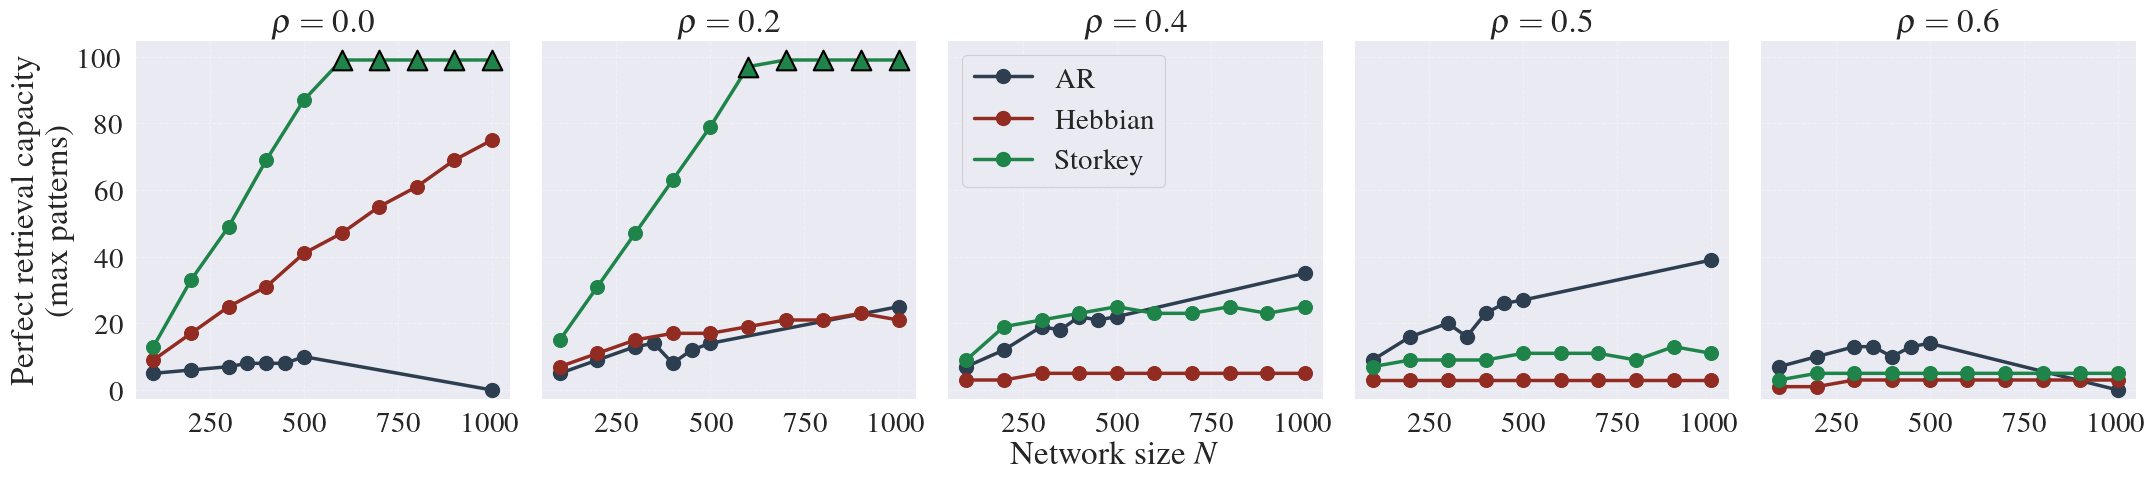

In [ ]:
# GENERATE SUMMARY FIGURE (1×5 row)
# =============================================================================

print("\n" + "=" * 70)
print("GENERATING SUMMARY FIGURE")
print(f"  - Rho values: {RHO_VALUES}")
print(f"  - Informed fraction: {int(INFORMED_FRACTION*100)}%")
print(f"  - Success threshold: {int(SUCCESS_THRESHOLD*100)}%")
print("=" * 70)

# Create figure with 5 subplots in a single row
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

# Adjust spacing (more bottom margin for centered x-label)
fig.subplots_adjust(wspace=0.08, left=0.07, right=0.98, bottom=0.16, top=0.88)

for col_idx, rho in enumerate(RHO_VALUES):
    ax = axes[col_idx]

    # --- AR (CHN) ---
    if chn_df is not None:
        ar_subset = filter_by_rho(chn_df, rho)
        if len(ar_subset) > 0:
            ar_pivot = compute_success_pivot(ar_subset, 'all_recovered_before_spurious')
            ar_caps = compute_capacity_monotonic(ar_pivot, SUCCESS_THRESHOLD)

            x_ar = sorted(ar_caps.keys())
            y_ar = [ar_caps[x] for x in x_ar]

            style = METHOD_STYLES['AR']
            ax.plot(x_ar, y_ar, label='AR', **style)

    # --- Hebbian (DHN) ---
    if hebbian_df is not None:
        heb_subset = filter_by_rho(hebbian_df, rho)
        heb_subset = filter_by_informed(heb_subset, INFORMED_FRACTION)

        if len(heb_subset) > 0:
            heb_pivot = compute_success_pivot(heb_subset, 'query_success_rate')
            heb_caps = compute_capacity_monotonic(heb_pivot, SUCCESS_THRESHOLD)
            heb_saturated = detect_saturation(heb_caps)

            x_heb = sorted(heb_caps.keys())
            y_heb = [heb_caps[x] for x in x_heb]
            x_normal = [x for x in x_heb if not heb_saturated[x]]
            y_normal = [heb_caps[x] for x in x_normal]
            x_sat = [x for x in x_heb if heb_saturated[x]]
            y_sat = [heb_caps[x] for x in x_sat]

            style = METHOD_STYLES['Hebbian']
            # Dummy plot for legend (invisible point)
            ax.plot([], [], label='Hebbian', **style)
            # Plot line through all points
            ax.plot(x_heb, y_heb, linestyle=style['linestyle'], color=style['color'],
                   linewidth=style['linewidth'])
            # Plot circle markers only at non-saturated points
            if x_normal:
                ax.scatter(x_normal, y_normal, marker='o', c=style['color'],
                          s=style['markersize']**2, zorder=5)
            # Plot triangles at saturated points
            if x_sat:
                ax.scatter(x_sat, y_sat, marker='^', c=style['color'],
                          s=200, edgecolors='black', linewidth=1.5, zorder=10)

    # --- Storkey (DHN) ---
    if storkey_df is not None:
        stk_subset = filter_by_rho(storkey_df, rho)
        stk_subset = filter_by_informed(stk_subset, INFORMED_FRACTION)

        if len(stk_subset) > 0:
            stk_pivot = compute_success_pivot(stk_subset, 'query_success_rate')
            stk_caps = compute_capacity_monotonic(stk_pivot, SUCCESS_THRESHOLD)
            stk_saturated = detect_saturation(stk_caps)

            x_stk = sorted(stk_caps.keys())
            y_stk = [stk_caps[x] for x in x_stk]
            x_normal = [x for x in x_stk if not stk_saturated[x]]
            y_normal = [stk_caps[x] for x in x_normal]
            x_sat = [x for x in x_stk if stk_saturated[x]]
            y_sat = [stk_caps[x] for x in x_sat]

            style = METHOD_STYLES['Storkey']
            # Dummy plot for legend (invisible point)
            ax.plot([], [], label='Storkey', **style)
            # Plot line through all points
            ax.plot(x_stk, y_stk, linestyle=style['linestyle'], color=style['color'],
                   linewidth=style['linewidth'])
            # Plot circle markers only at non-saturated points
            if x_normal:
                ax.scatter(x_normal, y_normal, marker='o', c=style['color'],
                          s=style['markersize']**2, zorder=5)
            # Plot triangles at saturated points
            if x_sat:
                ax.scatter(x_sat, y_sat, marker='^', c=style['color'],
                          s=200, edgecolors='black', linewidth=1.5, zorder=10)

    # Formatting
    ax.set_title(rf'$\rho = {rho}$', fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(-3, 105)  # Slightly below 0 to avoid cut markers
    ax.set_xlim(50, 1050)

    # Y-axis label only on leftmost subplot
    if col_idx == 0:
        ax.set_ylabel('Perfect retrieval capacity\n(max patterns)')

# Legend in the middle subplot (ρ=0.4, index 2)
axes[2].legend(loc='upper left', frameon=True, framealpha=0.9)

# Single centered x-axis label
fig.text(0.515, 0.02, 'Network size $N$', ha='center', va='bottom', fontsize=24, fontweight='bold')

if SAVE_PLOTS:
    output_path = OUTPUT_DIR / "comparison_summary.png"
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    print(f"\n  Saved to: {output_path}")

plt.show()

In [ ]:
# SUMMARY STATISTICS
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY STATISTICS (50% informed, 90% threshold)")
print("=" * 70)

print("\nCapacity by method and rho:")
print("-" * 50)

for rho in RHO_VALUES:
    print(f"\nρ = {rho}:")

    # Get capacities at N=500 (middle of range) for comparison
    target_n = 500

    # AR
    if chn_df is not None:
        ar_subset = filter_by_rho(chn_df, rho)
        if len(ar_subset) > 0:
            ar_pivot = compute_success_pivot(ar_subset, 'all_recovered_before_spurious')
            ar_caps = compute_capacity_monotonic(ar_pivot, SUCCESS_THRESHOLD)
            ar_cap = ar_caps.get(target_n, 'N/A')
            print(f"  AR:      {ar_cap} patterns (N={target_n})")

    # Hebbian
    if hebbian_df is not None:
        heb_subset = filter_by_rho(hebbian_df, rho)
        heb_subset = filter_by_informed(heb_subset, INFORMED_FRACTION)
        if len(heb_subset) > 0:
            heb_pivot = compute_success_pivot(heb_subset, 'query_success_rate')
            heb_caps = compute_capacity_monotonic(heb_pivot, SUCCESS_THRESHOLD)
            heb_saturated = detect_saturation(heb_caps)
            heb_cap = heb_caps.get(target_n, 'N/A')
            sat_marker = " (saturated)" if heb_saturated.get(target_n, False) else ""
            print(f"  Hebbian: {heb_cap} patterns (N={target_n}){sat_marker}")

    # Storkey
    if storkey_df is not None:
        stk_subset = filter_by_rho(storkey_df, rho)
        stk_subset = filter_by_informed(stk_subset, INFORMED_FRACTION)
        if len(stk_subset) > 0:
            stk_pivot = compute_success_pivot(stk_subset, 'query_success_rate')
            stk_caps = compute_capacity_monotonic(stk_pivot, SUCCESS_THRESHOLD)
            stk_saturated = detect_saturation(stk_caps)
            stk_cap = stk_caps.get(target_n, 'N/A')
            sat_marker = " (saturated)" if stk_saturated.get(target_n, False) else ""
            print(f"  Storkey: {stk_cap} patterns (N={target_n}){sat_marker}")


SUMMARY STATISTICS (50% informed, 90% threshold)

Capacity by method and rho:
--------------------------------------------------

ρ = 0.0:
  AR:      10 patterns (N=500)
  Hebbian: 41 patterns (N=500)
  Storkey: 87 patterns (N=500)

ρ = 0.2:
  AR:      14 patterns (N=500)
  Hebbian: 17 patterns (N=500)
  Storkey: 79 patterns (N=500)

ρ = 0.4:
  AR:      22 patterns (N=500)
  Hebbian: 5 patterns (N=500)
  Storkey: 25 patterns (N=500)

ρ = 0.5:
  AR:      27 patterns (N=500)
  Hebbian: 3 patterns (N=500)
  Storkey: 11 patterns (N=500)

ρ = 0.6:
  AR:      14 patterns (N=500)
  Hebbian: 3 patterns (N=500)
  Storkey: 5 patterns (N=500)


In [ ]:
# DONE
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY VISUALIZATION COMPLETE!")
print("=" * 70)

if SAVE_PLOTS:
    print(f"\nOutput: {OUTPUT_DIR / 'comparison_summary.png'}")

print("\nKey findings:")
print("  - At low ρ (0.0-0.2): DHN methods (especially Storkey) dominate")
print("  - At medium ρ (0.4-0.5): AR becomes competitive")
print("  - At higher ρ (0.6): AR outperforms DHN methods")

print("\n" + "=" * 70)


SUMMARY VISUALIZATION COMPLETE!

Output: /home/saighi/Desktop/AR_final/Autonomous_Recollection_CHN/simulations/main_write_sleep/scripts/plots/comparison_summary.png

Key findings:
  - At low ρ (0.0-0.2): DHN methods (especially Storkey) dominate
  - At medium ρ (0.4-0.5): AR becomes competitive
  - At higher ρ (0.6): AR outperforms DHN methods

